# Lab 1 of 8 — Feature engineering and feature selection

*Check the tools, understand the data, build features, and choose among them.*

**Goal.** Check the environment, engineer features, compare scaling, and select features without leakage.

Run this notebook from the folder that contains `all_datasets/`.

## Setup

In [1]:
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LogisticRegression, Ridge
from sklearn.metrics import mean_absolute_error, pairwise_distances, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def find_data_dir(name="all_datasets"):
    """Search this file's folder (or the working folder) and its parents for the data folder."""
    try:
        start = Path(__file__).resolve().parent
    except NameError:  # running as a notebook: no __file__
        start = Path.cwd()
    for folder in [start, *start.parents]:
        if (folder / name).is_dir():
            return folder / name
    raise FileNotFoundError(f"Could not find {name}/ in {start} or any parent folder")


# The lab's original `Path.cwd().parent` assumes notebooks live in all_experiments/;
# searching upward works from either layout.
DATA = find_data_dir()
PROJECT_ROOT = DATA.parent
print("Using data from:", DATA)

Using data from: c:\Users\azrai\Desktop\Machine Learning\all_datasets


## Part A — Environment check and a first look at the data

Record package versions for reproducibility.

In [2]:
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)

NumPy: 2.4.6
pandas: 3.0.3
Matplotlib: 3.10.9
scikit-learn: 1.9.0


Titanic has one row per passenger; `Survived=1` denotes survival. Inspect shape, types, missingness, and class balance.

In [3]:
df = pd.read_csv(DATA / "titanic_dataset.csv")
print("shape:", df.shape)
print(df.head())
print("\nData types:\n", df.dtypes)
print("\nSurvival rate:\n", df["Survived"].value_counts(normalize=True))

shape: (891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   

Plot missing-value percentages by column.

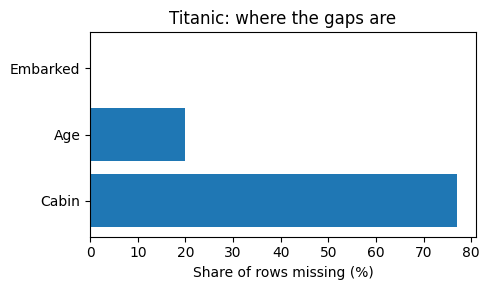

In [4]:
missing = df.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]
plt.figure(figsize=(5, 3))
plt.barh(missing.index, missing.values * 100)
plt.xlabel("Share of rows missing (%)")
plt.title("Titanic: where the gaps are")
plt.tight_layout()
plt.show()

**Inspect.** 891 passengers × 12 columns, and 38.4% survived, so the classes are moderately imbalanced (always predicting "died" would already be right 61.6% of the time). Three columns have gaps: `Cabin` (77.1% missing), `Age` (19.9%) and `Embarked` (0.2%, two rows). That is why imputation has to be part of the modelling pipeline, and why `Cabin` is too sparse to use naively (it returns in *Try it yourself*).

## Part B — Feature engineering

Derive family size, isolation, title, and log fare from prediction-time information. Each feature must exist *before* the outcome.

In [5]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["Title"] = df["Name"].str.extract(r",\s*([^\.]+)\.")[0].str.strip()
df["Title"] = df["Title"].where(df["Title"].isin(["Mr", "Mrs", "Miss", "Master"]), "Other")
df["LogFare"] = np.log1p(df["Fare"])
print(df[["Name", "Title", "FamilySize", "IsAlone", "Fare", "LogFare"]].head())
print("\nTitle counts:\n", df["Title"].value_counts())

                                                Name Title  FamilySize  \
0                            Braund, Mr. Owen Harris    Mr           2   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...   Mrs           2   
2                             Heikkinen, Miss. Laina  Miss           1   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)   Mrs           2   
4                           Allen, Mr. William Henry    Mr           1   

   IsAlone     Fare   LogFare  
0        0   7.2500  2.110213  
1        0  71.2833  4.280593  
2        1   7.9250  2.188856  
3        0  53.1000  3.990834  
4        1   8.0500  2.202765  

Title counts:
 Title
Mr        517
Miss      182
Mrs       125
Master     40
Other      27
Name: count, dtype: int64


Compare survival rates across engineered features.

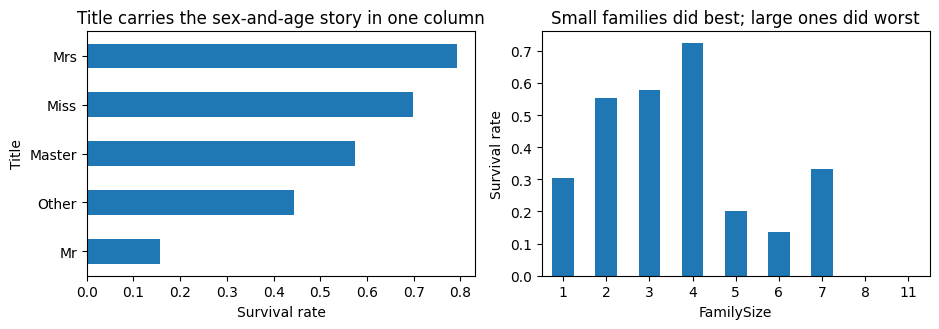

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))
df.groupby("Title")["Survived"].mean().sort_values().plot.barh(ax=axes[0])
axes[0].set_xlabel("Survival rate")
axes[0].set_title("Title carries the sex-and-age story in one column")
df.groupby("FamilySize")["Survived"].mean().plot.bar(ax=axes[1], rot=0)
axes[1].set_ylabel("Survival rate")
axes[1].set_title("Small families did best; large ones did worst")
plt.tight_layout()
plt.show()

**Inspect.** Survival climbs from 15.7% for `Mr` to 79.2% for `Mrs`, with `Miss` (69.8%) and `Master` (57.5%) in between: the title packs sex and rough age into one column. Passengers travelling alone survived at 30.4%, family sizes 2–4 did much better (55–72%), and sizes 5+ fell to 0–33%. Those largest families are tiny groups (6–22 passengers per size), so treat the right-hand bars as suggestive rather than precise.

Compare original and engineered features using the same model and split. Fit imputation, scaling, and encoding **inside** the training pipeline.

In [7]:
def make_preprocess(num_cols, cat_cols):
    return ColumnTransformer([
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols),
    ])


y = df["Survived"]
feature_sets = {
    "raw columns": (["Age", "SibSp", "Parch", "Fare"], ["Pclass", "Sex", "Embarked"]),
    "raw + engineered": (["Age", "SibSp", "Parch", "LogFare", "FamilySize", "IsAlone"],
                         ["Pclass", "Sex", "Embarked", "Title"]),
}
for name, (num_cols, cat_cols) in feature_sets.items():
    X = df[num_cols + cat_cols]
    X_train, X_valid, y_train, y_valid = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )
    model = Pipeline([
        ("preprocess", make_preprocess(num_cols, cat_cols)),
        ("model", LogisticRegression(max_iter=2000)),
    ]).fit(X_train, y_train)
    auc = roc_auc_score(y_valid, model.predict_proba(X_valid)[:, 1])
    print(f"{name:18s} validation ROC AUC = {auc:.3f}")

raw columns        validation ROC AUC = 0.842
raw + engineered   validation ROC AUC = 0.872


**Inspect.** Same estimator (logistic regression), same stratified 75/25 split, same seed: validation ROC AUC rises from 0.842 to 0.872. The gain measures the features (`Title`, `FamilySize`, `IsAlone`, `LogFare`), not a different model, and all of them are knowable at boarding, so none leaks the outcome. One split of 223 passengers is a noisy estimate; the cross-validated table in *Try it yourself* points the same way (0.851 → 0.873).

## Part C — Scaling changes the geometry

Breast-cancer measurements have unequal scales: area reaches thousands while smoothness is below one. Compare their effect on distances.

In [8]:
cancer = pd.read_csv(DATA / "breast_cancer_dataset.csv")
feature_cols = [c for c in cancer.columns if c not in {"id", "diagnosis", "Unnamed: 32"}]
X_cancer = cancer[feature_cols]
three = ["area_mean", "texture_mean", "smoothness_mean"]
print(X_cancer[three].describe().loc[["mean", "std"]].round(3))

      area_mean  texture_mean  smoothness_mean
mean    654.889        19.290            0.096
std     351.914         4.301            0.014


Compare raw and standardized distances among the first five tumors; darker heatmap cells indicate closer pairs.

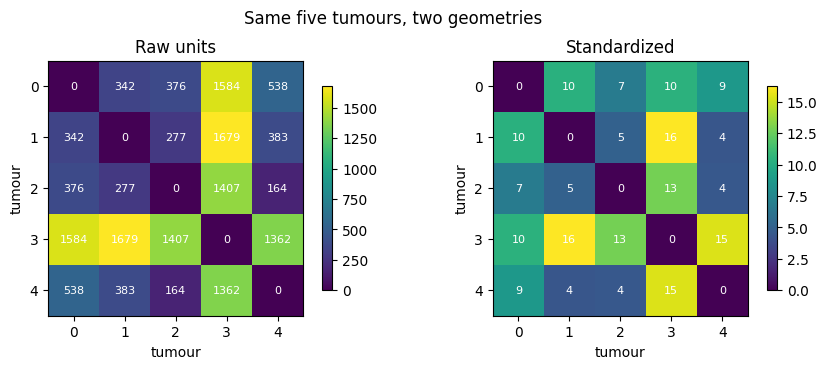

In [9]:
raw = pairwise_distances(X_cancer.iloc[:5], metric="euclidean")
X_scaled = StandardScaler().fit_transform(X_cancer)
scaled = pairwise_distances(X_scaled[:5], metric="euclidean")
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
for ax, matrix, title in [(axes[0], raw, "Raw units"), (axes[1], scaled, "Standardized")]:
    im = ax.imshow(matrix, cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel("tumour")
    ax.set_ylabel("tumour")
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f"{matrix[i, j]:.0f}", ha="center", va="center", color="white", fontsize=8)
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle("Same five tumours, two geometries")
plt.tight_layout()
plt.show()

Read the closest pair off each matrix directly (tumours are numbered as on the plot axes, starting at 0):

In [10]:
def closest_pair(matrix):
    """Return the (row, col) of the smallest off-diagonal distance."""
    rows, cols = np.triu_indices_from(matrix, k=1)
    nearest = np.argmin(matrix[rows, cols])
    return int(rows[nearest]), int(cols[nearest])


for label, matrix in [("raw units", raw), ("standardized", scaled)]:
    i, j = closest_pair(matrix)
    print(f"closest pair, {label:12s}: tumours {i} and {j} (distance {matrix[i, j]:.2f})")

closest pair, raw units   : tumours 2 and 4 (distance 164.15)
closest pair, standardized: tumours 1 and 4 (distance 4.38)


**Inspect.** The three columns live on very different scales: `area_mean` averages 654.9 (std 351.9), `texture_mean` 19.3 (std 4.3) and `smoothness_mean` 0.096 (std 0.014). In raw Euclidean distance, area dominates and smoothness barely registers.

The closest pair changes from tumours 3/5 to 2/5 after scaling. The lab counts tumours from 1, while the plot axes and the code above count from 0, so `(2, 4)` → `(1, 4)` is the same statement. The plot alone cannot show it for the standardized panel: cells (1, 4) and (2, 4) both display as "4" because the labels are rounded to whole numbers, and the exact distances above (4.38 for the winner) are what separate them. Units can change neighbours, which matters for any distance-based method such as k-NN or k-means.

One caveat: the scaler here was fitted on all 569 tumours. That is fine for illustrating geometry, but it is exactly what you must **not** do before scoring a model (see question 1 below).

## Part D — Feature selection without leakage

Predict `G3` for 649 students **at enrolment**. Exclude later grades `G1` and `G2`, leaving 30 candidate columns.

In [11]:
students = pd.read_csv(DATA / "student_performance_dataset.csv")
print("shape:", students.shape, " missing:", students.isna().sum().sum(),
      " duplicates:", students.duplicated().sum())
target = "G3"
leaky = ["G1", "G2"]
X_s = students.drop(columns=[target] + leaky)
y_s = students[target]
s_num = X_s.select_dtypes(include="number").columns.tolist()
s_cat = X_s.select_dtypes(exclude="number").columns.tolist()
print(len(s_num), "numeric and", len(s_cat), "text features available at enrolment")
Xs_train, Xs_valid, ys_train, ys_valid = train_test_split(X_s, y_s, test_size=0.25, random_state=42)

shape: (649, 33)  missing: 0  duplicates: 0
13 numeric and 17 text features available at enrolment


Compare ridge using all features or ten `SelectKBest` features, and lasso's sparse fit. Keep selection **inside** training pipelines.

In [12]:
def evaluate(pipeline, X_tr, X_va, label):
    pipeline.fit(X_tr, ys_train)
    mae = mean_absolute_error(ys_valid, pipeline.predict(X_va))
    print(f"{label:32s} validation MAE = {mae:.3f} grade points")
    return mae


results = {}
results["all 30 features"] = evaluate(Pipeline([
    ("preprocess", make_preprocess(s_num, s_cat)),
    ("model", Ridge(alpha=1.0)),
]), Xs_train, Xs_valid, "all 30 features")
results["SelectKBest, k=10"] = evaluate(Pipeline([
    ("preprocess", make_preprocess(s_num, s_cat)),
    ("select", SelectKBest(f_regression, k=10)),
    ("model", Ridge(alpha=1.0)),
]), Xs_train, Xs_valid, "SelectKBest, k=10")
lasso = Pipeline([
    ("preprocess", make_preprocess(s_num, s_cat)),
    ("model", Lasso(alpha=0.1)),
])
results["lasso (selects itself)"] = evaluate(lasso, Xs_train, Xs_valid, "lasso (selects itself)")

all 30 features                  validation MAE = 2.181 grade points


SelectKBest, k=10                validation MAE = 2.139 grade points
lasso (selects itself)           validation MAE = 2.077 grade points


A fourth run deliberately adds `G2` to expose leakage.

In [13]:
leak_num = s_num + ["G2"]
results["all 30 + G2 (leakage)"] = evaluate(Pipeline([
    ("preprocess", make_preprocess(leak_num, s_cat)),
    ("model", Ridge(alpha=1.0)),
]), Xs_train.assign(G2=students.loc[Xs_train.index, "G2"]),
    Xs_valid.assign(G2=students.loc[Xs_valid.index, "G2"]), "all 30 + G2 (leakage)")

all 30 + G2 (leakage)            validation MAE = 0.762 grade points

lasso kept 19 of 56 encoded columns
num__failures            -0.94
cat__higher_no           -0.79
num__Dalc                -0.35
cat__reason_other        -0.23
num__health              -0.18
num__freetime            -0.02
num__goout               -0.01
num__absences            -0.01
num__traveltime          -0.01
cat__schoolsup_yes       -0.00
cat__school_MS           -0.00
cat__higher_yes           0.00
cat__reason_reputation    0.04
num__famrel               0.10
num__Fedu                 0.10
num__Medu                 0.17
num__studytime            0.33
cat__schoolsup_no         0.36
cat__school_GP            1.11


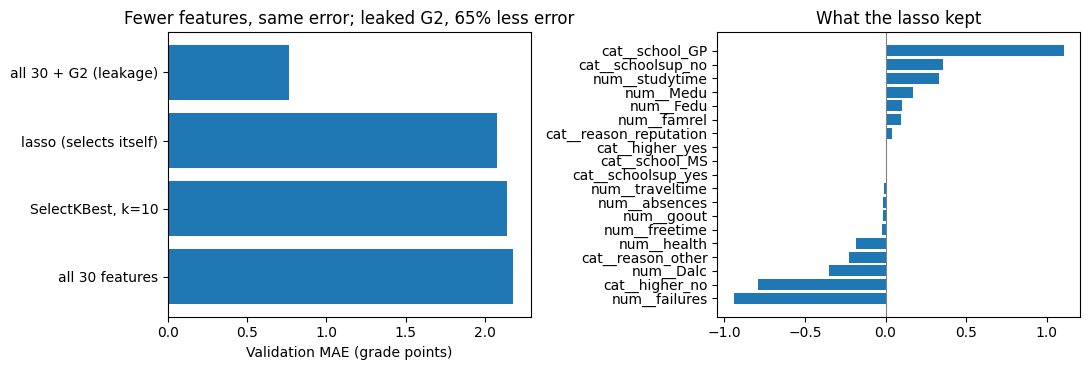

In [14]:
coefs = pd.Series(lasso.named_steps["model"].coef_,
                  index=lasso.named_steps["preprocess"].get_feature_names_out())
kept = coefs[coefs != 0].sort_values()
print(f"lasso kept {len(kept)} of {len(coefs)} encoded columns")
print(kept.round(2).to_string())
# The lab's title claimed the leak "halves" the error; compute the measured drop instead.
leak_drop = 1 - results["all 30 + G2 (leakage)"] / results["all 30 features"]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].barh(list(results), list(results.values()))
axes[0].set_xlabel("Validation MAE (grade points)")
axes[0].set_title(f"Fewer features, same error; leaked G2, {leak_drop:.0%} less error")
axes[1].barh(kept.index, kept.values)
axes[1].axvline(0, color="grey", linewidth=0.8)
axes[1].set_title("What the lasso kept")
plt.tight_layout()
plt.show()

**Inspect.** With only enrolment-time information, ridge on all 30 columns (56 after one-hot encoding) has validation MAE 2.18 grade points. `SelectKBest` with k=10 gets 2.14 and the lasso 2.08, so similar or slightly better error from fewer columns (the lasso kept 19 of 56). Differences of a few hundredths of a grade point on 163 validation students are within split-to-split noise, so read this as "no accuracy lost", not "selection wins". For scale, predicting every student's grade as the overall mean gives an MAE of about 2.4 (computed on all 649 students), so what is knowable at enrolment explains only a modest share of `G3`.

Adding `G2` drops MAE from 2.18 to 0.76 (about 65% lower). It is not a better model; it is a different question. `G2` is a later grade that correlates 0.92 with `G3`, and it does not exist at enrolment, so that score is not an honest forecast of what we could know at that moment.

What the lasso kept: `school_GP` (+1.11) and `failures` (−0.94) dominate, followed by `higher_no` (−0.79), workday alcohol `Dalc` (−0.35), `schoolsup_no` (+0.36), `studytime` (+0.33), and parents' education `Medu`/`Fedu` (+0.17/+0.10). These are associations in one sample from two schools, not causal effects. For example, a positive `schoolsup_no` coefficient may simply mean that students who receive extra support were already struggling; the lasso cannot tell us that.

## Try it yourself

**1. Titanic: add cabin initial and fare per family member, then compare with Part B.**

Two caveats shape how to read this. `Fare` on Titanic is usually the price of a whole *ticket*, so dividing by `FamilySize` gives a rough per-person fare. And a single 25% split of 891 rows leaves only 223 validation passengers, so small AUC gaps can be noise; I add 5-fold cross-validated AUC (still with all preprocessing inside the pipeline) as a steadier second opinion.

In [15]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

df["CabinDeck"] = df["Cabin"].str[0].fillna("Unknown")
df["FarePerPerson"] = df["Fare"] / df["FamilySize"]
df["LogFarePerPerson"] = np.log1p(df["FarePerPerson"])

engineered_num = ["Age", "SibSp", "Parch", "LogFare", "FamilySize", "IsAlone"]
engineered_cat = ["Pclass", "Sex", "Embarked", "Title"]
variants = {
    "raw columns": (["Age", "SibSp", "Parch", "Fare"], ["Pclass", "Sex", "Embarked"]),
    "raw + engineered (Part B)": (engineered_num, engineered_cat),
    "+ cabin deck": (engineered_num, engineered_cat + ["CabinDeck"]),
    "+ fare per person": (engineered_num + ["LogFarePerPerson"], engineered_cat),
    "+ both": (engineered_num + ["LogFarePerPerson"], engineered_cat + ["CabinDeck"]),
}


def titanic_pipeline(num_cols, cat_cols):
    return Pipeline([
        ("preprocess", make_preprocess(num_cols, cat_cols)),
        ("model", LogisticRegression(max_iter=2000)),
    ])


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rows = []
for name, (num_cols, cat_cols) in variants.items():
    X = df[num_cols + cat_cols]
    X_train, X_valid, y_train, y_valid = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )
    fitted = titanic_pipeline(num_cols, cat_cols).fit(X_train, y_train)
    cv_auc = cross_val_score(titanic_pipeline(num_cols, cat_cols), X, y, cv=cv, scoring="roc_auc")
    rows.append({
        "feature set": name,
        "validation AUC": roc_auc_score(y_valid, fitted.predict_proba(X_valid)[:, 1]),
        "5-fold CV AUC": cv_auc.mean(),
        "CV std": cv_auc.std(),
    })
print(pd.DataFrame(rows).set_index("feature set").round(3))

                           validation AUC  5-fold CV AUC  CV std
feature set                                                     
raw columns                         0.842          0.851   0.022
raw + engineered (Part B)           0.872          0.873   0.016
+ cabin deck                        0.868          0.875   0.020
+ fare per person                   0.872          0.873   0.016
+ both                              0.868          0.874   0.020


**Inspect.** Neither addition helps measurably. On the fixed split, AUC goes from 0.872 to 0.868 with cabin deck and stays at 0.872 with fare per person. Cross-validated AUC moves by at most 0.002 (0.873 → 0.875 / 0.873 / 0.874), far smaller than the fold-to-fold standard deviation of about 0.02. That is plausible: `Pclass` and `LogFare` already carry most of what these two features add (cabins are mostly recorded for first-class passengers).

Cabin also raises the lab's moment-of-prediction question. `CabinDeck` is "Unknown" for 77% of passengers, and it is often reported that cabin information for this dataset was compiled after the sinking, more completely for survivors. If so, "has a recorded cabin" could carry outcome information that would not exist at boarding. Even with no accuracy gain to tempt us, that is a reason to be cautious about using it.

**2. Part D again with `k=5` and `k=20`.**

`SelectKBest` chooses among the *encoded* columns (after one-hot encoding), so `k` is counted against a larger pool than the 30 original columns. The `k=10` row should reproduce the number from Part D.

In [16]:
n_encoded = make_preprocess(s_num, s_cat).fit(Xs_train).get_feature_names_out().size
print(f"{len(s_num) + len(s_cat)} original columns -> {n_encoded} encoded columns after one-hot encoding\n")

k_results = {}
for k in (5, 10, 20):
    label = f"SelectKBest, k={k}"
    k_results[label] = evaluate(Pipeline([
        ("preprocess", make_preprocess(s_num, s_cat)),
        ("select", SelectKBest(f_regression, k=k)),
        ("model", Ridge(alpha=1.0)),
    ]), Xs_train, Xs_valid, label)

comparison = pd.Series({
    "all 30 features": results["all 30 features"],
    **k_results,
    "lasso (selects itself)": results["lasso (selects itself)"],
}, name="validation MAE").round(3)
print("\n", comparison.to_string(), sep="")

30 original columns -> 56 encoded columns after one-hot encoding

SelectKBest, k=5                 validation MAE = 2.134 grade points


SelectKBest, k=10                validation MAE = 2.139 grade points


SelectKBest, k=20                validation MAE = 2.125 grade points

all 30 features           2.181
SelectKBest, k=5          2.134
SelectKBest, k=10         2.139
SelectKBest, k=20         2.125
lasso (selects itself)    2.077


**Inspect.** Validation MAE barely moves with k: 2.134 (k=5), 2.139 (k=10) and 2.125 (k=20), against 2.181 with every column and 2.077 for the lasso. The entire spread across k is 0.014 grade points, on grades that run 0–19 in this data. Five selected columns already match twenty. Note that k counts *encoded* columns, so even k=20 keeps only about a third of the 56. With this data and a ridge model, selection buys simplicity rather than accuracy, and the lasso's small edge comes from a single split, so I would not lean on it.

## Check your understanding

**1. Why must train/test splitting happen before any preprocessing step that learns from the data?**

Imputers, scalers, encoders and feature selectors all *learn* something from the data: medians, means and standard deviations, category lists, feature scores. If they are fitted before the split, the validation rows help decide those numbers, so information about the "unseen" data leaks into training and the validation score comes out too optimistic. Splitting first and fitting every step on the training rows only (which is what `Pipeline` + `ColumnTransformer` do: `.fit` sees `X_train`, and validation rows are only *transformed*) keeps the validation set a fair stand-in for future data. `SelectKBest` is the sharpest case, because it looks at `y`: choosing features on the full data before splitting is a direct route to inflated scores.

**2. What is the difference between an identifier, a feature, and a label?**

- **Label:** what we are trying to predict (`Survived`, `G3`, `diagnosis`). It is never an input.
- **Feature:** a measurable input that is available at prediction time and can carry signal that generalizes (`Pclass`, `Age`, `studytime`). Engineered columns such as `Title` and `FamilySize` are features derived from other inputs.
- **Identifier:** a value that names a row without describing it (`PassengerId`, `id` in the cancer data, the raw `Name` string). It carries no signal that transfers to new rows; at best it is noise, at worst it lets a flexible model memorise rows or exploit file ordering. Drop it, or extract a real feature from it, as `Title` is extracted from `Name`.

The roles are set by the task, not by the column: `Name` is an identifier, but `Title` pulled out of it is a feature.

**3. Why do you need to know the moment of prediction before you can say whether a feature is leakage?**

Leakage is defined relative to time, not to the column itself: a feature leaks if its value would not be known at the moment the prediction is made, or if it is a consequence of the outcome. The same column can be legitimate for one forecast and leaky for another. `G2` is the example in this lab: for a forecast made at enrolment it does not exist yet, so using it (MAE 0.76 instead of 2.18) reports a score that could never be reproduced in real use. For a forecast made after the second-period grades are in, `G2` would be a perfectly valid and very valuable feature. Without fixing the moment of prediction first, there is no way to tell which features are fair. The same reasoning is why `Cabin` deserves a question mark for the Titanic model.